# Klasifikasi Aksara Jawa — CNN Pipeline

**Tugas:** Mengklasifikasikan 20 karakter dasar Aksara Jawa (Hanacaraka) menggunakan CNN.

**Struktur kode:**
```
src/
├── config.py          ← Hyperparameter & path
├── dataset.py         ← PyTorch Dataset & DataLoader
├── model.py           ← Arsitektur SimpleCNN
├── engine.py          ← Train loop, evaluasi, metrics
└── explainability.py  ← Grad-CAM
```

**Prerequisite:** `download_dataset.py` sudah dijalankan, folder `dataset/{train,val,test}` sudah ada.

In [2]:
# Setup path agar module di src/ bisa di-import
import sys
from pathlib import Path
sys.path.insert(0, str(Path('src').resolve()))

import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
    force=True,
)

import random
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from config import get_config, CLASSES, IDX_TO_CLASS
from dataset import build_dataloaders, build_transforms, AksaraJawaDataset
from model import SimpleCNN, count_parameters
from engine import fit, detailed_evaluation, evaluate
from explainability import GradCAM, overlay_cam_on_image
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

## 1. Konfigurasi & Reproducibility

In [3]:
cfg = get_config()

# Set seed di SEMUA library yang relevan untuk reproducibility
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

# Deterministic mode: lebih lambat tapi reproducible
# Comment kalau prioritas kecepatan
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {device}')
print(f'PyTorch version : {torch.__version__}')
if device.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print(f'\nConfig:')
for k, v in vars(cfg).items():
    print(f'  {k:25s} = {v}')

Device          : cuda
PyTorch version : 2.11.0+cu128
GPU             : NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory      : 4.3 GB

Config:
  data_dir                  = dataset
  artifact_dir              = artifacts
  checkpoint_name           = best_model.pt
  image_size                = 96
  in_channels               = 1
  num_workers               = 0
  pin_memory                = True
  norm_mean                 = (0.1,)
  norm_std                  = (0.25,)
  batch_size                = 64
  epochs                    = 50
  learning_rate             = 0.0012
  weight_decay              = 0.0001
  warmup_epochs             = 2
  label_smoothing           = 0.05
  grad_clip_norm            = 1.0
  aug_rotation_deg          = 8.0
  aug_translate             = 0.08
  aug_scale                 = (0.9, 1.1)
  aug_shear_deg             = 5.0
  aug_brightness            = 0.1
  aug_contrast              = 0.1
  aug_erasing_prob          = 0.15
  dropout                   = 0.4
  early_

## 2. Build DataLoaders

In [4]:
loaders, datasets = build_dataloaders(cfg)

print('Dataset size:')
for split, ds in datasets.items():
    print(f'  {split:6s}: {len(ds):>5} samples → {len(loaders[split]):>3} batches')

print(f'\nBatch shape (train): ', end='')
x_batch, y_batch = next(iter(loaders['train']))
print(f'images={tuple(x_batch.shape)}, labels={tuple(y_batch.shape)}')
print(f'Pixel range  : [{x_batch.min():.3f}, {x_batch.max():.3f}]  (sudah dinormalisasi)')

Index ha:   0%|          | 0/190 [00:00<?, ?it/s]

Index na:   0%|          | 0/203 [00:00<?, ?it/s]

Index ca:   0%|          | 0/203 [00:00<?, ?it/s]

Index ra:   0%|          | 0/197 [00:00<?, ?it/s]

Index ka:   0%|          | 0/205 [00:00<?, ?it/s]

...

Index ga:   0%|          | 0/35 [00:00<?, ?it/s]

Index ba:   0%|          | 0/44 [00:00<?, ?it/s]

Index tha:   0%|          | 0/43 [00:00<?, ?it/s]

Index nga:   0%|          | 0/44 [00:00<?, ?it/s]

Dataset size:
  train :  3898 samples →  60 batches
  val   :   836 samples →  14 batches
  test  :   848 samples →  14 batches

Batch shape (train): images=(64, 1, 96, 96), labels=(64,)
Pixel range  : [-0.400, 3.600]  (sudah dinormalisasi)


## 3. Visualisasi Augmentasi

Cek apakah augmentasi terlalu agresif atau terlalu lemah. Augmentasi yang baik harus tetap mempertahankan identitas karakter.

Index ha:   0%|          | 0/190 [00:00<?, ?it/s]

Index na:   0%|          | 0/203 [00:00<?, ?it/s]

Index ca:   0%|          | 0/203 [00:00<?, ?it/s]

Index ra:   0%|          | 0/197 [00:00<?, ?it/s]

Index ka:   0%|          | 0/205 [00:00<?, ?it/s]

...

Index ma:   0%|          | 0/204 [00:00<?, ?it/s]

Index ga:   0%|          | 0/161 [00:00<?, ?it/s]

Index ba:   0%|          | 0/205 [00:00<?, ?it/s]

Index tha:   0%|          | 0/200 [00:00<?, ?it/s]

Index nga:   0%|          | 0/201 [00:00<?, ?it/s]

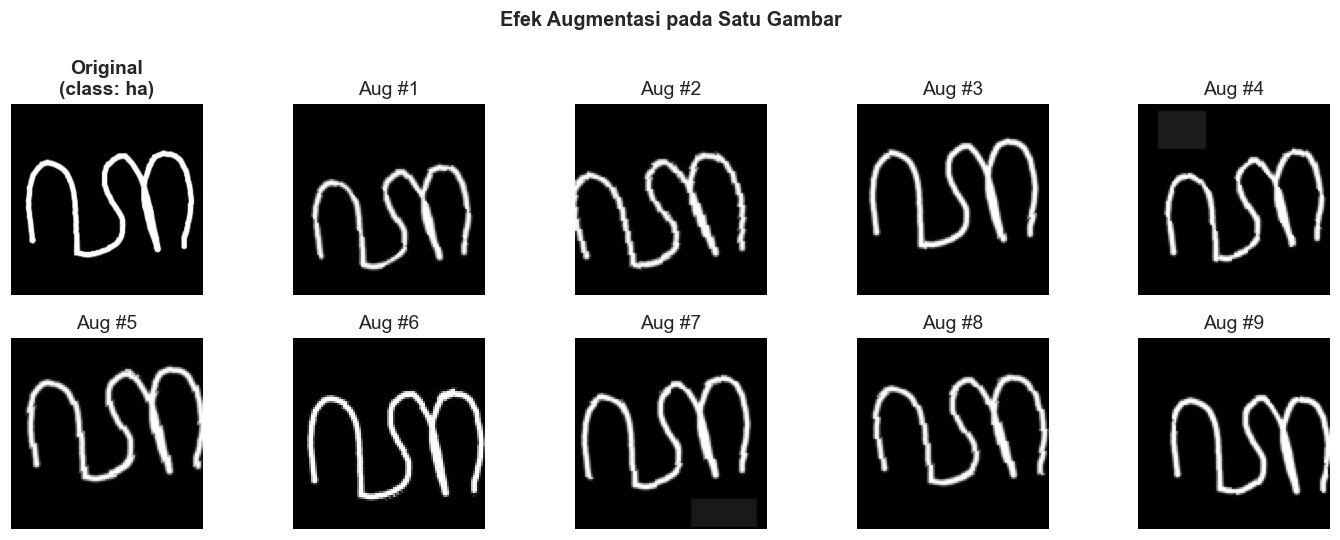

In [5]:
from PIL import Image

def denormalize(tensor, mean, std):
    """Reverse normalisasi untuk visualisasi."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor.clamp(0, 1)

# Ambil satu gambar mentah lalu apply transform 8x untuk lihat variasi
train_tf, _ = build_transforms(cfg)
raw_dataset = AksaraJawaDataset(cfg.data_dir / 'train', transform=None)
raw_img, raw_label = raw_dataset[0]

fig, axes = plt.subplots(2, 5, figsize=(13, 5))

# Original (column 0)
axes[0, 0].imshow(raw_img, cmap='gray')
axes[0, 0].set_title(f'Original\n(class: {IDX_TO_CLASS[raw_label]})', fontweight='bold')
axes[0, 0].axis('off')
axes[1, 0].axis('off')

# 9 augmented variants
for i in range(1, 10):
    ax = axes[i // 5, i % 5]
    augmented = train_tf(raw_img)
    img_denorm = denormalize(augmented, cfg.norm_mean, cfg.norm_std)
    ax.imshow(img_denorm.squeeze().numpy(), cmap='gray')
    ax.set_title(f'Aug #{i}')
    ax.axis('off')

plt.suptitle('Efek Augmentasi pada Satu Gambar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/augmentation_preview.png', bbox_inches='tight', dpi=110)
plt.show()

## 4. Arsitektur Model

**ImprovedCNN** — 4 conv blocks → AdaptiveAvgPool → two-layer FC head (256→128→20).

Perbaikan atas SimpleCNN:
1. **Two-layer FC head** `256→128→20` dengan BatchNorm1d dan Dropout berlapis  
2. **BatchNorm1d** setelah hidden FC: stabilkan representasi sebelum classifier  
3. **Dropout 0.4** (FC1) dan **0.2** (FC2): regularisasi berlapis

Total ~424K parameter vs ~393K SimpleCNN — kenaikan modest ~8% dengan kapasitas representasi lebih kaya.

In [6]:
model = SimpleCNN(
    num_classes=20,
    in_channels=cfg.in_channels,
    dropout=cfg.dropout,
).to(device)

total, trainable = count_parameters(model)
print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}')
print(f'Memory (approx)      : {total * 4 / 1e6:.2f} MB (fp32)')
print()
print(model)

Total parameters     : 393,460
Trainable parameters : 393,460
Memory (approx)      : 1.57 MB (fp32)

SimpleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d

In [7]:
# Verifikasi shape feature map di setiap layer
print('Output shape per layer (input: 1×1×64×64):')
print('─' * 55)
x = torch.randn(1, cfg.in_channels, cfg.image_size, cfg.image_size).to(device)
model.eval()
with torch.no_grad():
    for i, layer in enumerate(model.features):
        x = layer(x)
        print(f'  features[{i}] {type(layer).__name__:20s} → {tuple(x.shape)}')
    print('─' * 55)
    x_flat = model.classifier[0](x)
    print(f'  Flatten              → {tuple(x_flat.shape)}')
    x_out = model.classifier(x)
    print(f'  Final logits         → {tuple(x_out.shape)}')

Output shape per layer (input: 1×1×64×64):
───────────────────────────────────────────────────────
  features[0] Sequential           → (1, 32, 48, 48)
  features[1] Sequential           → (1, 64, 24, 24)
  features[2] Sequential           → (1, 128, 12, 12)
  features[3] Conv2d               → (1, 256, 12, 12)
  features[4] BatchNorm2d          → (1, 256, 12, 12)
  features[5] ReLU                 → (1, 256, 12, 12)
  features[6] AdaptiveAvgPool2d    → (1, 256, 1, 1)
───────────────────────────────────────────────────────
  Flatten              → (1, 256)
  Final logits         → (1, 20)


## 5. Training

- **Optimizer:** AdamW (Adam + decoupled weight decay) — lebih stabil dari Adam vanilla
- **Scheduler:** Linear warmup (2 epoch) → Cosine annealing
- **Loss:** CrossEntropy dengan label smoothing 0.05 — cegah overconfidence
- **Early stopping:** patience 7 epoch berdasarkan val accuracy
- **AMP (Mixed Precision):** auto-enable jika GPU available — 2x speedup

In [8]:
metrics, ckpt_path = fit(model, loaders, cfg, device)
print(f'\nCheckpoint terbaik tersimpan di: {ckpt_path}')

19:56:03 [INFO] Mixed precision (AMP): enabled


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Train batches:   0%|          | 0/60 [00:00<?, ?it/s]

Eval batches:   0%|          | 0/14 [00:00<?, ?it/s]

19:56:26 [INFO] Epoch   1/50 | train_loss=3.1530 acc=0.0552 | val_loss=3.0909 acc=0.0789 | lr=6.00e-04 | 22.7s
19:56:26 [INFO]   → New best val_acc=0.0789, saved to best_model.pt


...

20:08:35 [INFO] Epoch  49/50 | train_loss=1.0399 acc=0.7961 | val_loss=0.8919 acc=0.8493 | lr=1.28e-06 | 15.0s


Train batches:   0%|          | 0/60 [00:00<?, ?it/s]

Eval batches:   0%|          | 0/14 [00:00<?, ?it/s]

20:08:51 [INFO] Epoch  50/50 | train_loss=1.0364 acc=0.7966 | val_loss=0.8934 acc=0.8565 | lr=0.00e+00 | 15.5s
20:08:51 [INFO] Training done. Best val_acc = 0.8589



Checkpoint terbaik tersimpan di: artifacts\best_model.pt


## 6. Training Curves

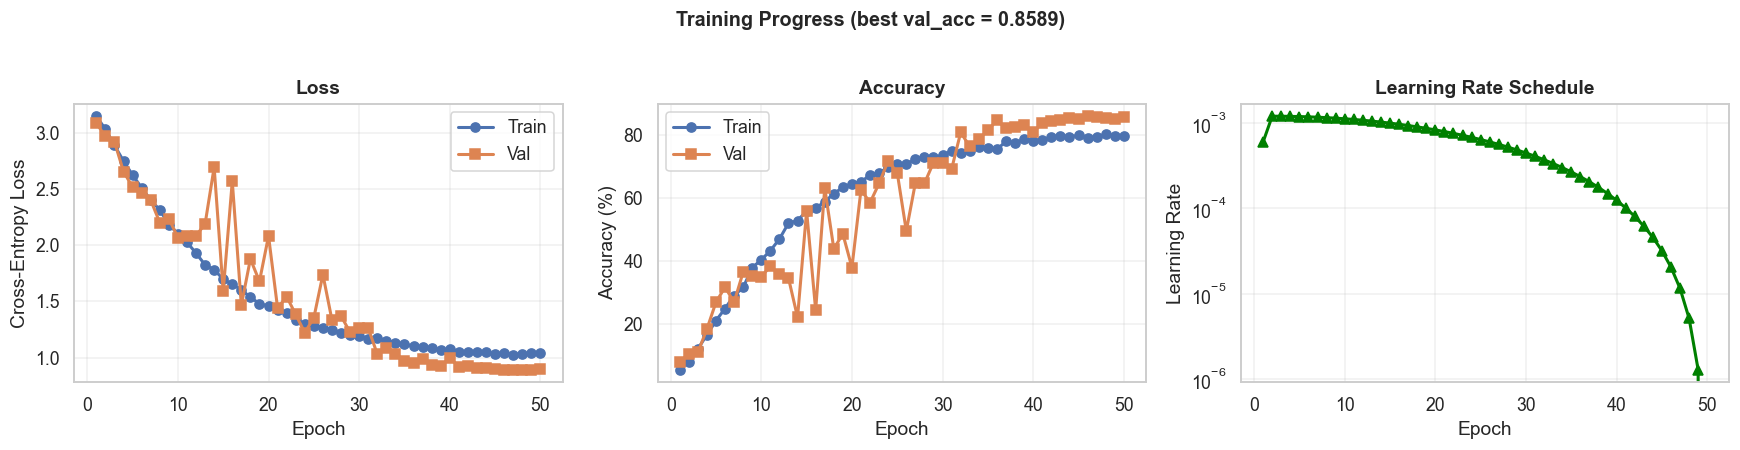


Final train-val accuracy gap: -5.98%
Train-val gap dalam batas wajar.


In [9]:
epochs = range(1, len(metrics.train_loss) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(epochs, metrics.train_loss, label='Train', marker='o', linewidth=2)
axes[0].plot(epochs, metrics.val_loss, label='Val', marker='s', linewidth=2)
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, [a * 100 for a in metrics.train_acc], label='Train', marker='o', linewidth=2)
axes[1].plot(epochs, [a * 100 for a in metrics.val_acc], label='Val', marker='s', linewidth=2)
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning rate schedule
axes[2].plot(epochs, metrics.lr, color='green', marker='^', linewidth=2)
axes[2].set_title('Learning Rate Schedule', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.suptitle(f'Training Progress (best val_acc = {max(metrics.val_acc):.4f})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('artifacts/training_curves.png', bbox_inches='tight', dpi=110)
plt.show()

# Diagnose overfitting/underfitting
final_gap = metrics.train_acc[-1] - metrics.val_acc[-1]
print(f'\nFinal train-val accuracy gap: {final_gap * 100:.2f}%')
if final_gap > 0.10:
    print('Overfitting terdeteksi (gap > 10%). Pertimbangkan:')
    print('   - Tambah dropout / weight decay')
    print('   - Augmentasi lebih agresif')
    print('   - Kurangi model capacity')
elif metrics.val_acc[-1] < 0.80:
    print('Underfitting / accuracy rendah. Pertimbangkan:')
    print('   - Train lebih lama (epoch lebih banyak)')
    print('   - Kurangi augmentasi')
    print('   - Cek apakah dataset terkontaminasi noise berat')
else:
    print('Train-val gap dalam batas wajar.')

## 7. Evaluasi pada Test Set

In [10]:
# Load best checkpoint sebelum eval
ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded checkpoint dari epoch {ckpt["epoch"]} (val_acc={ckpt["val_acc"]:.4f})')

results = detailed_evaluation(model, loaders['test'], device, CLASSES)

print('\n' + '═' * 50)
print('HASIL EVALUASI PADA TEST SET')
print('═' * 50)
print(f'Loss              : {results["loss"]:.4f}')
print(f'Accuracy          : {results["accuracy"] * 100:.2f}%')
print(f'Precision (macro) : {results["precision_macro"] * 100:.2f}%')
print(f'Recall    (macro) : {results["recall_macro"] * 100:.2f}%')
print(f'F1-score  (macro) : {results["f1_macro"] * 100:.2f}%')
print('═' * 50)

Loaded checkpoint dari epoch 46 (val_acc=0.8589)


Eval batches:   0%|          | 0/14 [00:00<?, ?it/s]


══════════════════════════════════════════════════
HASIL EVALUASI PADA TEST SET
══════════════════════════════════════════════════
Loss              : 0.5916
Accuracy          : 87.85%
Precision (macro) : 87.50%
Recall    (macro) : 87.23%
F1-score  (macro) : 87.12%
══════════════════════════════════════════════════


### Classification Report (per kelas)

In [11]:
print(results['classification_report'])

              precision    recall  f1-score   support

          ha     0.5532    0.6341    0.5909        41
          na     0.9070    0.8864    0.8966        44
          ca     0.9318    0.9318    0.9318        44
          ra     0.9302    0.9302    0.9302        43
          ka     0.8958    0.9556    0.9247        45
          da     0.9250    0.8222    0.8706        45
          ta     0.8108    0.8333    0.8219        36
          sa     0.8571    0.9333    0.8936        45
          wa     0.8837    0.9500    0.9157        40
          la     0.6522    0.4167    0.5085        36
          pa     0.9130    0.9545    0.9333        44
         dha     0.9070    0.9070    0.9070        43
          ja     0.9500    0.8837    0.9157        43
          ya     0.8462    0.9778    0.9072        45
         nya     0.8750    0.9545    0.9130        44
          ma     0.9130    0.9545    0.9333        44
          ga     0.8710    0.7714    0.8182        35
          ba     0.9250    

### Confusion Matrix

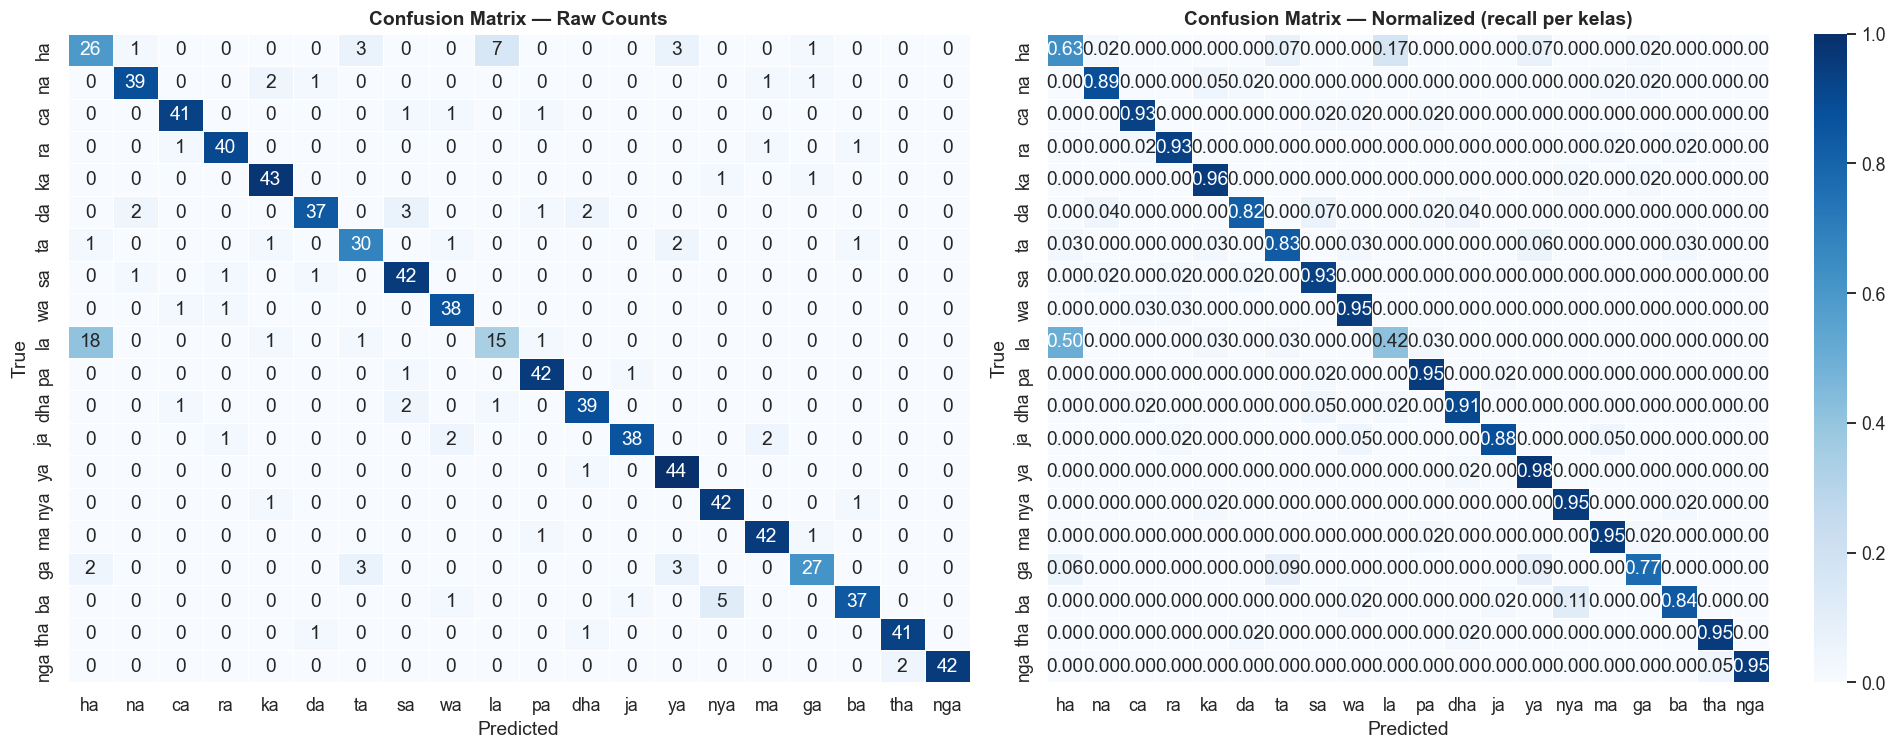


5 kelas dengan recall terendah:
  la    : recall = 0.417 (15/36)
  ha    : recall = 0.634 (26/41)
  ga    : recall = 0.771 (27/35)
  da    : recall = 0.822 (37/45)
  ta    : recall = 0.833 (30/36)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(
    results['confusion_matrix'],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=axes[0], cbar=False, linewidths=0.5,
)
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized (per baris = recall)
cm_norm = results['confusion_matrix'].astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_norm, row_sums, where=row_sums != 0)

sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=axes[1], cbar=True, linewidths=0.5, vmin=0, vmax=1,
)
axes[1].set_title('Confusion Matrix — Normalized (recall per kelas)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', bbox_inches='tight', dpi=110)
plt.show()

# Identify hardest classes
diag = np.diag(cm_norm)
worst_idx = np.argsort(diag)[:5]
print('\n5 kelas dengan recall terendah:')
for idx in worst_idx:
    print(f'  {CLASSES[idx]:6s}: recall = {diag[idx]:.3f} ({int(np.diag(results["confusion_matrix"])[idx])}/{int(results["confusion_matrix"][idx].sum())})')

### Per-Class F1 Score

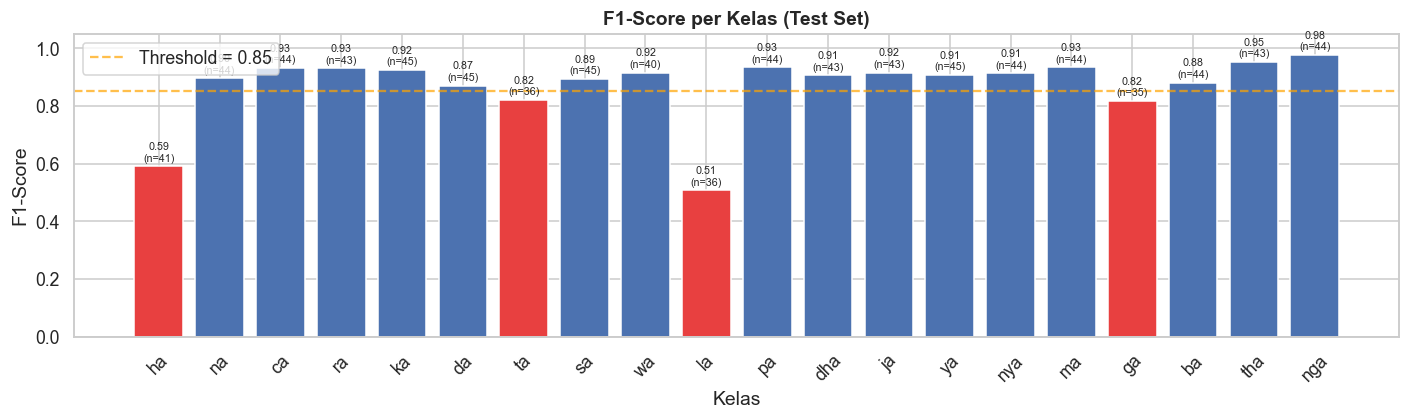

In [13]:
f1_per_class = results['per_class_f1']
support      = results['per_class_support']

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#E84040' if f1 < 0.85 else '#4C72B0' for f1 in f1_per_class]
bars = ax.bar(CLASSES, f1_per_class, color=colors, edgecolor='white')
ax.axhline(0.85, color='orange', linestyle='--', alpha=0.7, label='Threshold = 0.85')
ax.set_title('F1-Score per Kelas (Test Set)', fontweight='bold')
ax.set_xlabel('Kelas')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=45)
ax.legend()

for bar, f1, n in zip(bars, f1_per_class, support):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{f1:.2f}\n(n={n})',
        ha='center', va='bottom', fontsize=7,
    )

plt.tight_layout()
plt.savefig('artifacts/per_class_f1.png', bbox_inches='tight', dpi=110)
plt.show()

## 8. Grad-CAM — Interpretasi Model

**Tujuan:** Visualisasi area gambar mana yang CNN fokus untuk membuat prediksi.

**Rumus matematis:**

$$\alpha_k^c = \frac{1}{Z}\sum_{i,j} \frac{\partial y^c}{\partial A_{ij}^k}$$

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha_k^c \cdot A^k\right)$$

Dimana:
- $A^k$ = feature map ke-$k$ pada conv layer terakhir
- $y^c$ = logit untuk kelas $c$
- $\alpha_k^c$ = bobot importance feature map $k$ untuk kelas $c$ (rata-rata gradien)

Target layer: Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


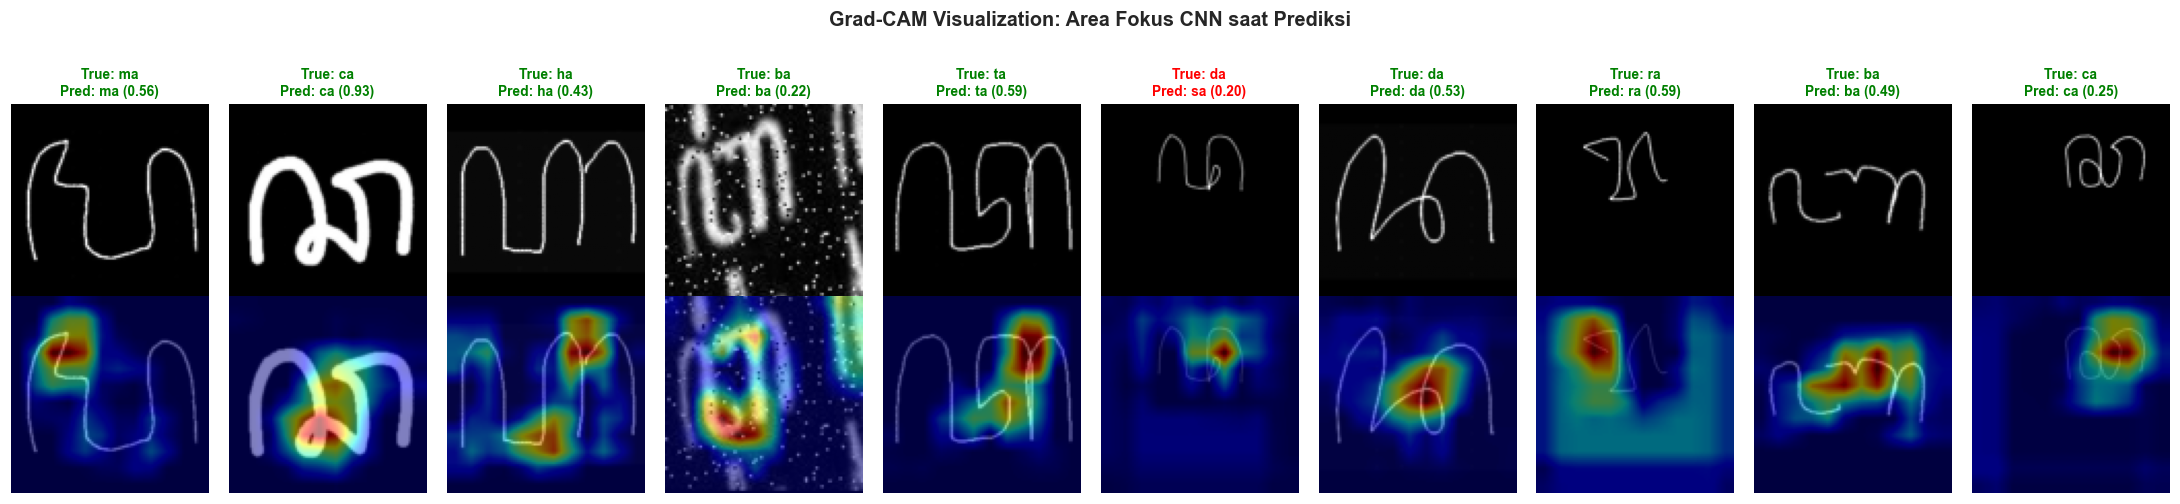

In [14]:
# Target layer: conv terakhir di features (index -4 = Conv2d sebelum BN+ReLU+AvgPool)
target_layer = model.features[-4]
print(f'Target layer: {target_layer}')

cam = GradCAM(model, target_layer)

# Pilih 10 sampel acak dari test set
import random
random.seed(42)
n_samples = 10
indices = random.sample(range(len(datasets['test'])), n_samples)

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 2, 4.5))

for col, idx in enumerate(indices):
    img_tensor, true_label = datasets['test'][idx]
    img_input = img_tensor.unsqueeze(0).to(device)

    cam_map, pred_class, confidence = cam(img_input)

    # Denormalize untuk display
    img_display = denormalize(img_tensor, cfg.norm_mean, cfg.norm_std).squeeze().numpy()

    # Row 0: original
    axes[0, col].imshow(img_display, cmap='gray')
    color = 'green' if pred_class == true_label else 'red'
    axes[0, col].set_title(
        f'True: {IDX_TO_CLASS[true_label]}\nPred: {IDX_TO_CLASS[pred_class]} ({confidence:.2f})',
        fontsize=9, color=color, fontweight='bold',
    )
    axes[0, col].axis('off')

    # Row 1: Grad-CAM overlay
    overlay = overlay_cam_on_image(img_display, cam_map, alpha=0.5)
    axes[1, col].imshow(overlay)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Grad-CAM', fontsize=10, fontweight='bold')

plt.suptitle('Grad-CAM Visualization: Area Fokus CNN saat Prediksi',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('artifacts/gradcam_samples.png', bbox_inches='tight', dpi=110)
plt.show()

cam.remove_hooks()  # PENTING: cleanup hooks untuk hindari memory leak

## 9. Analisis Error: Sampel yang Salah Diprediksi

Inspeksi visual sampel yang misclassified — apakah karena noise data, ambiguitas tulisan, atau weakness model?

Total kesalahan: 103 dari 848 samples
Error rate     : 12.15%


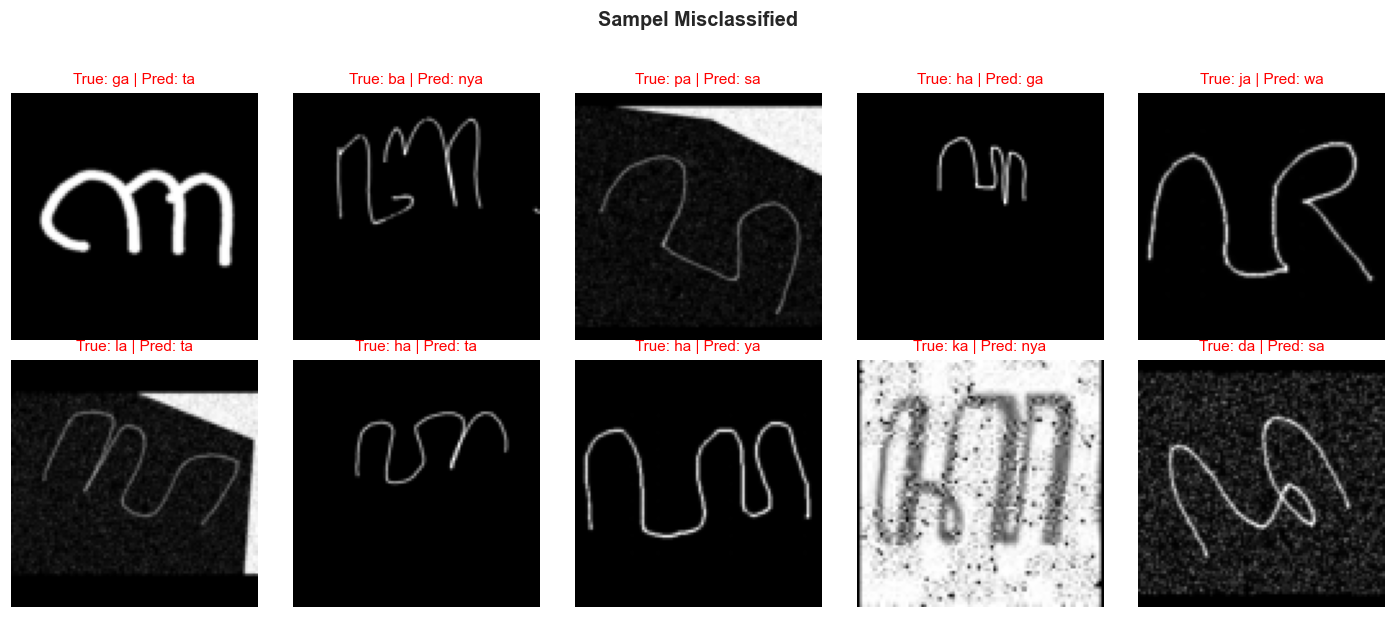

In [15]:
preds  = results['predictions']
labels = results['labels']

wrong_indices = np.where(preds != labels)[0]
print(f'Total kesalahan: {len(wrong_indices)} dari {len(labels)} samples')
print(f'Error rate     : {len(wrong_indices) / len(labels) * 100:.2f}%')

if len(wrong_indices) > 0:
    n_show = min(10, len(wrong_indices))
    sampled = random.sample(list(wrong_indices), n_show)

    fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
    for i, idx in enumerate(sampled):
        ax = axes[i // 5, i % 5]
        img_tensor, _ = datasets['test'][idx]
        img_display = denormalize(img_tensor, cfg.norm_mean, cfg.norm_std).squeeze().numpy()
        ax.imshow(img_display, cmap='gray')
        ax.set_title(
            f'True: {IDX_TO_CLASS[labels[idx]]} | Pred: {IDX_TO_CLASS[preds[idx]]}',
            fontsize=10, color='red',
        )
        ax.axis('off')

    plt.suptitle('Sampel Misclassified', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('artifacts/error_analysis.png', bbox_inches='tight', dpi=110)
    plt.show()